# 📊 Naive Bayes - Crop Recommendation

## Overview
Naive Bayes is a **probabilistic classification algorithm** based on Bayes' theorem with the "naive" assumption of feature independence. Despite its simplicity, it often performs surprisingly well and is particularly effective for text classification and multi-class problems.

### Key Concepts:
- **Bayes' Theorem**: `P(A|B) = P(B|A) × P(A) / P(B)`
- **Naive Assumption**: Features are conditionally independent given the class
- **Maximum A Posteriori (MAP)**: Predicts the class with highest posterior probability
- **Probability Estimation**: Uses training data to estimate class and feature probabilities

### How Naive Bayes Works:
1. **Training Phase**: 
   - Calculate prior probabilities: P(Class)
   - Calculate likelihood: P(Feature|Class) for each feature-class combination
   - Store probability distributions

2. **Prediction Phase**:
   - For each class, calculate posterior probability: P(Class|Features)
   - Use Bayes' theorem: P(Class|Features) ∝ P(Features|Class) × P(Class)
   - Predict class with highest posterior probability

### Types of Naive Bayes:
- **GaussianNB**: Assumes features follow Gaussian (normal) distribution
  - Best for continuous features
  - Uses mean and variance to model feature distributions

- **MultinomialNB**: Assumes features follow multinomial distribution
  - Best for discrete counts (e.g., word counts in text)
  - Uses frequency counts

- **BernoulliNB**: Assumes features are binary (0/1)
  - Best for binary features
  - Uses presence/absence of features

- **ComplementNB**: Variant of MultinomialNB
  - Better for imbalanced datasets

### Advantages:
- Fast training and prediction
- Works well with small datasets
- Handles multi-class problems naturally
- Not sensitive to irrelevant features
- Provides probability estimates
- Good baseline model

### Disadvantages:
- Strong independence assumption (often violated in practice)
- Can be outperformed by more sophisticated algorithms
- Requires feature independence (naive assumption)

### When to Use:
- Text classification (spam detection, sentiment analysis)
- Multi-class classification problems
- When you need probability estimates
- As a baseline model
- When training speed is important

## 1. Imports and Setup

In [ ]:
!pip install scikit-learn numpy pandas matplotlib seaborn

In [2]:
# =============================================================================
# 1. IMPORTS
# =============================================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    cross_validate,
    learning_curve
)
from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB,
    BernoulliNB,
    ComplementNB
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

## 2. Data Loading and Exploration

In [3]:
# =============================================================================
# 2. DATA LOADING
# =============================================================================

data_url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/crop_recommendation/train_set_label.csv"
df = pd.read_csv(data_url)


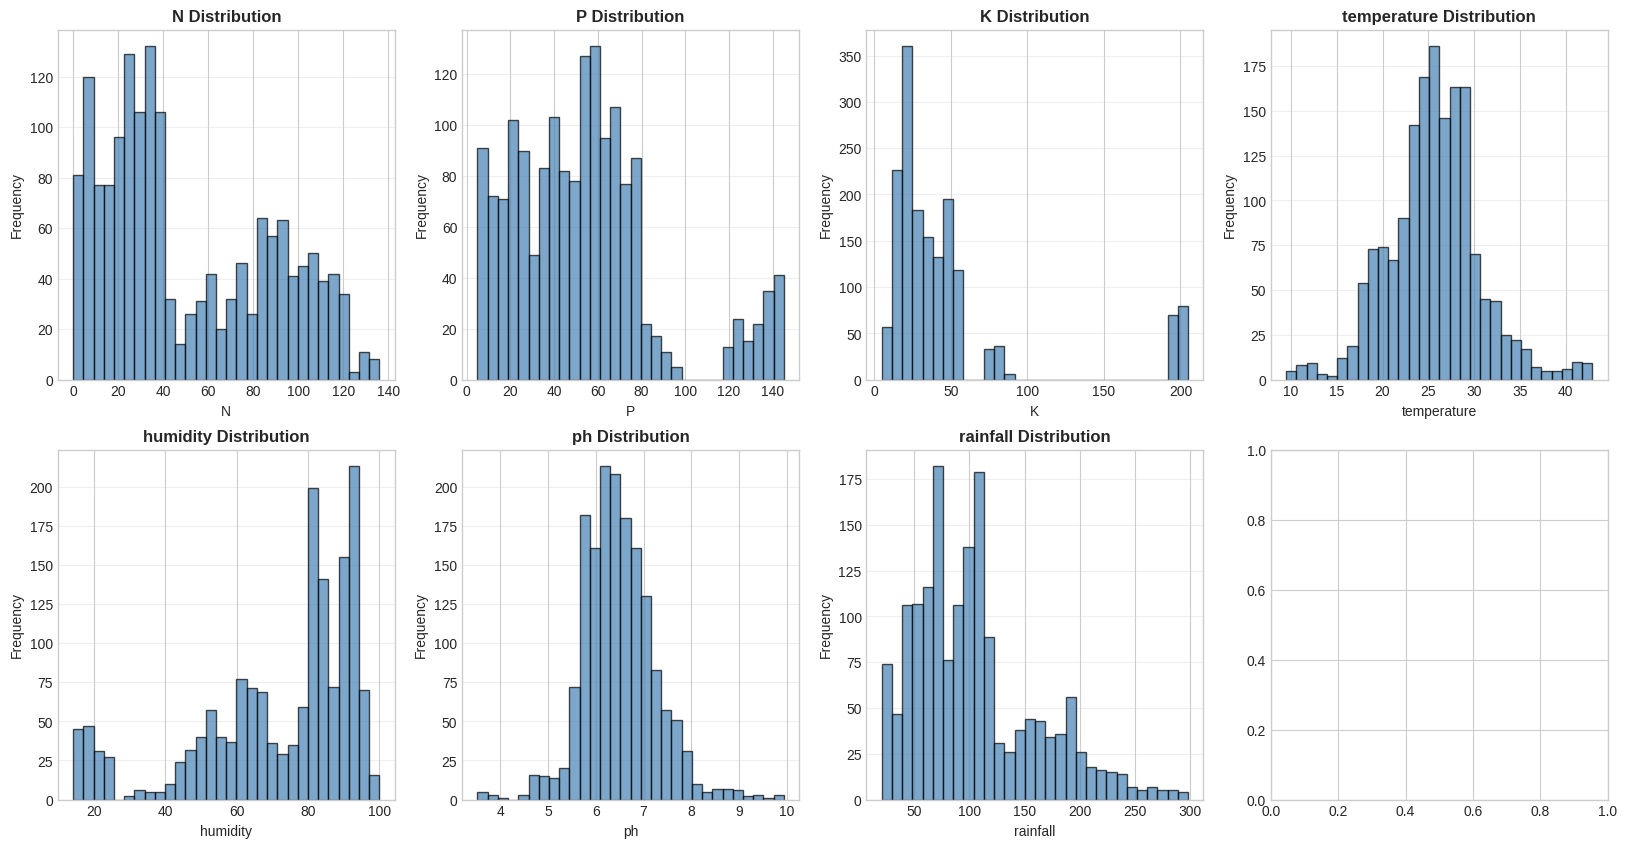

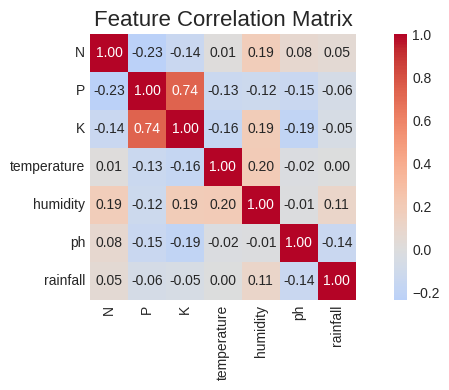


⚠️ Note: Naive Bayes assumes feature independence.
High correlations violate this assumption but the algorithm can still work.


In [10]:
# =============================================================================
# 3. EXPLORATORY DATA ANALYSIS
# =============================================================================

# Feature columns
feature_col = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

# Check feature distributions (important for Naive Bayes)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(feature_col):
    df[col].hist(bins=30, ax=axes[i], alpha=0.7, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)


# Correlation matrix
corr = df[feature_col].corr()
plt.figure(figsize=(8, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

print("\n⚠️ Note: Naive Bayes assumes feature independence.")
print("High correlations violate this assumption but the algorithm can still work.")

## 3. Data Preprocessing

In [12]:
# =============================================================================
# 4. FEATURE PREPARATION
# =============================================================================

# Separate features and target
X = df[feature_col]
y = df['crop']

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n📊 Train-Test Split:")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Features: {X_train.shape[1]}")


📊 Train-Test Split:
  Training set: 1320 samples
  Test set: 330 samples
  Features: 7


In [13]:
# =============================================================================
# 5. FEATURE SCALING (Optional for GaussianNB)
# =============================================================================
# Note: GaussianNB doesn't require scaling, but it can help with numerical stability
# MultinomialNB and BernoulliNB don't use scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Baseline Gaussian Naive Bayes Model

In [14]:

# Create baseline GaussianNB
nb_baseline = GaussianNB(
    var_smoothing=1e-09  # Default smoothing parameter
)

# Train the model
nb_baseline.fit(X_train_scaled, y_train)

# Predictions
y_pred_baseline = nb_baseline.predict(X_test_scaled)

# Evaluate
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(y_test, y_pred_baseline, average='weighted')
recall_baseline = recall_score(y_test, y_pred_baseline, average='weighted')
f1_baseline = f1_score(y_test, y_pred_baseline, average='weighted')

print(f"\n📊 Baseline GaussianNB Results:")
print(f"   Accuracy:  {accuracy_baseline:.4f} ({accuracy_baseline*100:.2f}%)")
print(f"   Precision: {precision_baseline:.4f}")
print(f"   Recall:    {recall_baseline:.4f}")
print(f"   F1-Score:  {f1_baseline:.4f}")



📊 Baseline GaussianNB Results:
   Accuracy:  0.9909 (99.09%)
   Precision: 0.9924
   Recall:    0.9909
   F1-Score:  0.9908


### 📚 GaussianNB Parameters Explanation

#### **`var_smoothing=1e-09`** (Variance Smoothing)
- **Purpose**: Adds a small value to all variances for numerical stability
- **Why needed**: Prevents division by zero when a feature has zero variance
- **Default**: 1e-09 (very small)
- **Effect**: 
  - Very small values (1e-10): More sensitive, can overfit
  - Larger values (1e-5): More smoothing, more robust but less precise
- **Tuning**: Usually kept at default, but can be tuned for better performance

<Figure size 800x400 with 0 Axes>

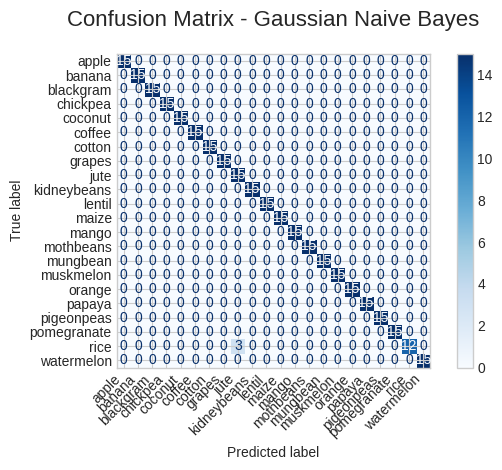

In [16]:
# =============================================================================
# 11. CONFUSION MATRIX
# =============================================================================

cm = confusion_matrix(y_test, y_pred_baseline)

# Visualize confusion matrix
plt.figure(figsize=(8, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Gaussian Naive Bayes', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## 8. Probability Analysis

📊 Probability Estimates Analysis:

Confidence Statistics:
  Mean confidence: 0.9923
  Std confidence:  0.0446
  Min confidence:  0.5465
  Max confidence:  1.0000


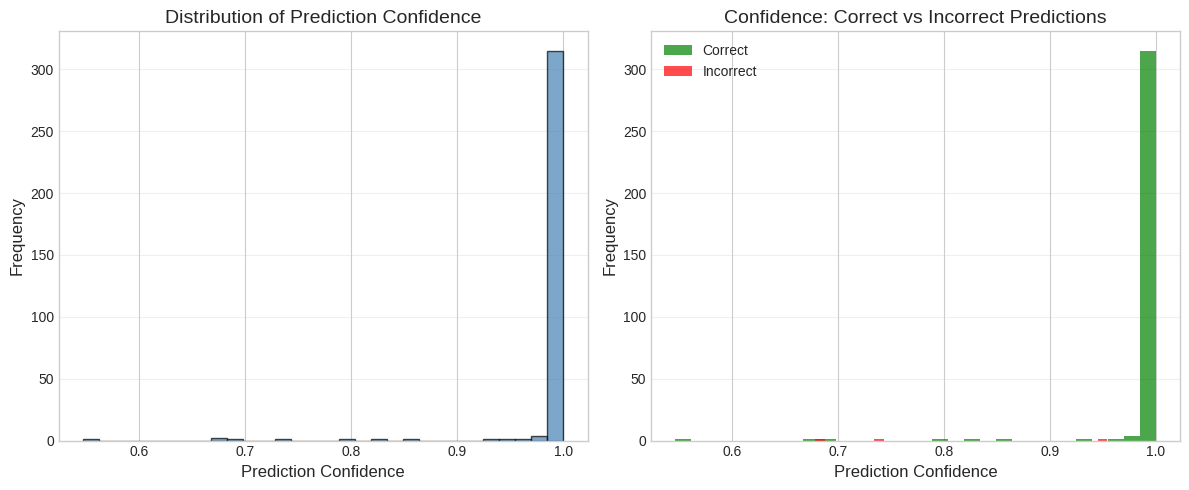

In [24]:
# =============================================================================
# 12. PROBABILITY ANALYSIS
# =============================================================================
# One advantage of Naive Bayes is that it provides probability estimates

print("📊 Probability Estimates Analysis:")

# Get probability estimates for test set
y_proba = nb_baseline.predict_proba(X_test_scaled)

# Find predictions with highest confidence
max_proba = np.max(y_proba, axis=1)
predicted_classes = np.argmax(y_proba, axis=1)

print(f"\nConfidence Statistics:")
print(f"  Mean confidence: {np.mean(max_proba):.4f}")
print(f"  Std confidence:  {np.std(max_proba):.4f}")
print(f"  Min confidence:  {np.min(max_proba):.4f}")
print(f"  Max confidence:  {np.max(max_proba):.4f}")

# Visualize confidence distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(max_proba, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Confidence', fontsize=14)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
# Compare confidence for correct vs incorrect predictions
correct_mask = (predicted_classes == y_test)
plt.hist(max_proba[correct_mask], bins=30, alpha=0.7, label='Correct', color='green')
plt.hist(max_proba[~correct_mask], bins=30, alpha=0.7, label='Incorrect', color='red')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Confidence: Correct vs Incorrect Predictions', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import joblib
from pathlib import Path

model_obj = None
for name in ["nb_baseline", "model", "best_model", "naive_bayes_model"]:
    if name in globals():
        model_obj = globals()[name]
        break

if model_obj is None:
    raise ValueError("No trained model variable found in notebook globals.")

output_path = Path("../../models/naive_bayes.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(model_obj, output_path)
print(f"Saved model to: {output_path.resolve()}")